# Apple Stock Price Analysis - Last 10 Years

This notebook extracts and visualizes the last 10 years of daily Apple (AAPL) stock price data from Yahoo Finance.

## 1. Import Required Libraries

Import necessary libraries including yfinance for data extraction, pandas for data manipulation, and matplotlib for visualization.

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

## 2. Download Apple Stock Data

Use yfinance to download 10 years of daily Apple (AAPL) stock price data, specifying the date range from today back 10 years.

In [2]:
# Calculate date range - last 10 years
end_date = datetime.now()
start_date = end_date - timedelta(days=365*10)

# Fetch Apple stock data
print("Fetching Apple (AAPL) stock data from Yahoo Finance...")
apple_data = yf.download('AAPL', start=start_date, end=end_date, progress=False)

print(f"\n✓ Successfully retrieved {len(apple_data)} trading days of data")
print(f"Date Range: {apple_data.index[0].date()} to {apple_data.index[-1].date()}")

Fetching Apple (AAPL) stock data from Yahoo Finance...

✓ Successfully retrieved 2512 trading days of data
Date Range: 2016-04-08 to 2026-04-06


## 3. Data Exploration and Preparation

Explore the downloaded data by displaying basic statistics, checking for missing values, and preparing the data for visualization.

In [4]:
# Clean up the data structure
apple_data.columns = apple_data.columns.droplevel('Ticker')

# Display first few rows
print("First few rows of data:")
print(apple_data.head())

print("\n" + "="*60)
print("Data Statistics:")
print("="*60)

# Display basic statistics for the Close price
close_prices = apple_data['Close']
print(f"\nClosing Price Statistics:")
print(f"  Lowest:  ${close_prices.min():.2f}")
print(f"  Highest: ${close_prices.max():.2f}")
print(f"  Average: ${close_prices.mean():.2f}")
print(f"  Latest:  ${close_prices.iloc[-1]:.2f}")

# Check for missing values
missing_values = apple_data.isnull().sum()
print(f"\nMissing Values: {missing_values.sum()}")
print(f"Data Shape: {apple_data.shape}")
print(f"Total Days: {len(apple_data)}")

First few rows of data:
Price           Close       High        Low       Open     Volume
Date                                                             
2016-04-08  24.609369  24.860761  24.498393  24.665989   94326800
2016-04-11  24.690899  25.051004  24.647869  24.679576  117630000
2016-04-12  25.012505  25.026093  24.609370  24.763375  108929200
2016-04-13  25.374870  25.442813  25.094035  25.094035  133029200
2016-04-14  25.388458  25.454138  25.214069  25.279749  101895600

Data Statistics:

Closing Price Statistics:
  Lowest:  $20.58
  Highest: $285.92
  Average: $120.30
  Latest:  $259.34

Missing Values: 0
Data Shape: (2512, 5)
Total Days: 2512


## 4. Create Price Chart Visualization

Create an interactive chart showing the daily closing price trend over the 10-year period with appropriate labels and formatting.

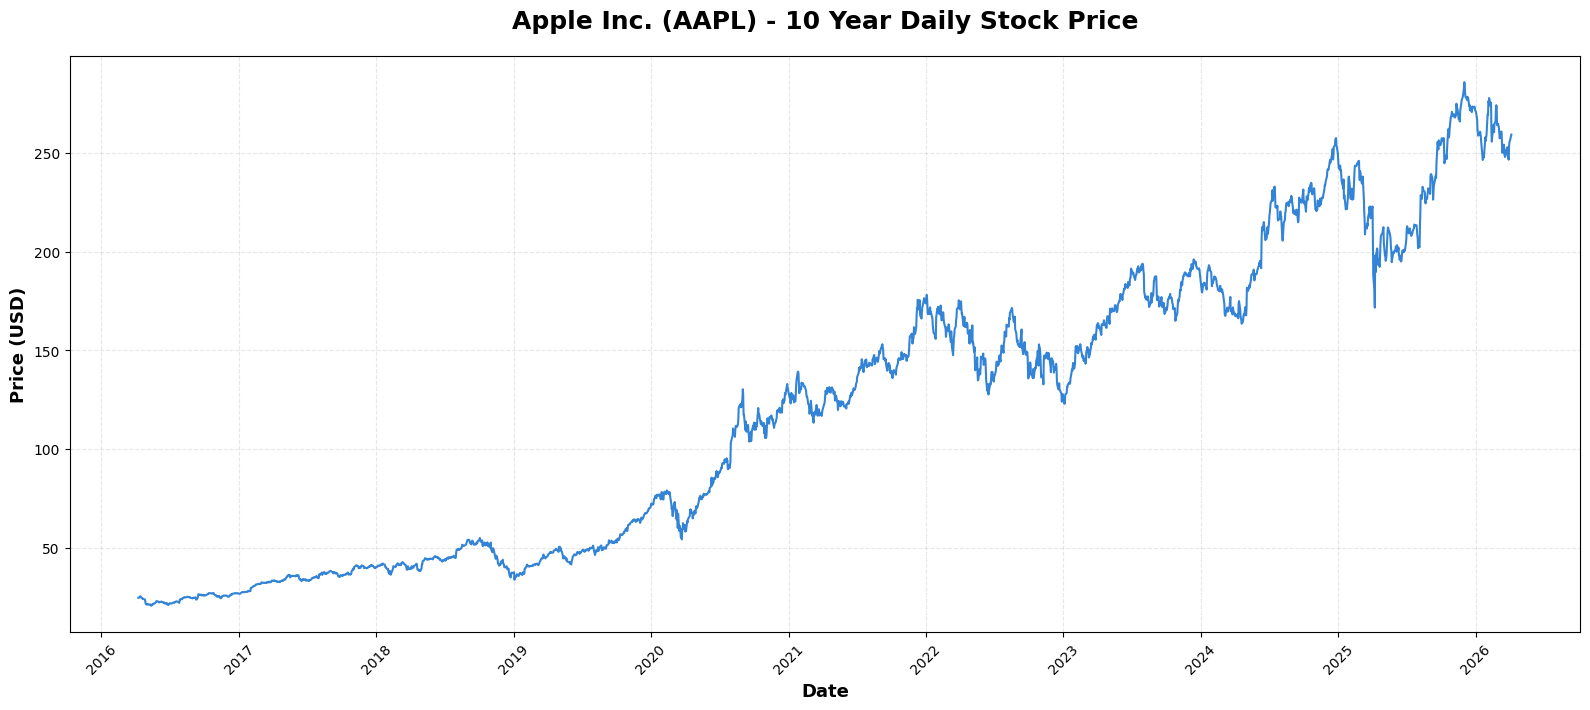

✓ Chart created successfully!


In [5]:
# Create a figure with larger size for better visibility
plt.figure(figsize=(16, 7))

# Plot the closing price
plt.plot(apple_data.index, apple_data['Close'], linewidth=1.5, color='#0066cc', alpha=0.8)

# Add title and labels
plt.title('Apple Inc. (AAPL) - 10 Year Daily Stock Price', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=13, fontweight='bold')
plt.ylabel('Price (USD)', fontsize=13, fontweight='bold')

# Add grid for better readability
plt.grid(True, alpha=0.3, linestyle='--')

# Format the plot
plt.tight_layout()
plt.xticks(rotation=45)

# Display the chart
plt.show()

print("✓ Chart created successfully!")

## 5. Prophet Time Series Forecasting

Install Facebook Prophet and prepare data for training and testing.

In [6]:
from prophet import Prophet
from sklearn.metrics import mean_squared_error
import numpy as np
from datetime import timedelta

# Prepare data for Prophet (needs 'ds' and 'y' columns)
df_prophet = apple_data.reset_index()[['Date', 'Close']].copy()
df_prophet.columns = ['ds', 'y']

# Define time periods
today = df_prophet['ds'].max()
four_years_ago = today - timedelta(days=365*4)
six_months_ago = today - timedelta(days=180)

print(f"Data Timeline:")
print(f"  Full Data: {df_prophet['ds'].min().date()} to {today.date()}")
print(f"  4 Years Ago: {four_years_ago.date()}")
print(f"  6 Months Ago: {six_months_ago.date()}")

# Create training and test sets
# Training: Last 4 years
train_data = df_prophet[df_prophet['ds'] >= four_years_ago].copy()

# Test: Last 6 months
test_data = df_prophet[(df_prophet['ds'] >= six_months_ago) & (df_prophet['ds'] <= today)].copy()

print(f"\nData Split:")
print(f"  Training Data: {len(train_data)} days ({train_data['ds'].min().date()} to {train_data['ds'].max().date()})")
print(f"  Test Data: {len(test_data)} days ({test_data['ds'].min().date()} to {test_data['ds'].max().date()})")

Data Timeline:
  Full Data: 2016-04-08 to 2026-04-06
  4 Years Ago: 2022-04-07
  6 Months Ago: 2025-10-08

Data Split:
  Training Data: 1001 days (2022-04-07 to 2026-04-06)
  Test Data: 123 days (2025-10-08 to 2026-04-06)


### Train Prophet Model on 4-Year Training Data

In [7]:
# Initialize and train Prophet model
print("Training Prophet Model...")
model = Prophet(
    yearly_seasonality=True,
    daily_seasonality=False,
    weekly_seasonality=True,
    interval_width=0.95
)

# Fit model on training data
model.fit(train_data)
print("✓ Model trained successfully!")

Training Prophet Model...


19:57:36 - cmdstanpy - INFO - Chain [1] start processing
19:57:38 - cmdstanpy - INFO - Chain [1] done processing


✓ Model trained successfully!


### Evaluate Model on Test Data and Calculate RMSE

In [8]:
# Create test forecast using the trained model
test_forecast = model.predict(test_data[['ds']])

# Merge predictions with actual test data for comparison
test_comparison = test_data.merge(test_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']], on='ds')

# Calculate RMSE on test data
actual_values = test_comparison['y'].values
predicted_values = test_comparison['yhat'].values
rmse = np.sqrt(mean_squared_error(actual_values, predicted_values))
mae = np.mean(np.abs(actual_values - predicted_values))

print("="*60)
print("MODEL EVALUATION ON TEST DATA (Last 6 Months)")
print("="*60)
print(f"\nRoot Mean Square Error (RMSE): ${rmse:.2f}")
print(f"Mean Absolute Error (MAE):    ${mae:.2f}")
print(f"\nActual Price Range on Test:")
print(f"  Min:  ${actual_values.min():.2f}")
print(f"  Max:  ${actual_values.max():.2f}")
print(f"  Mean: ${actual_values.mean():.2f}")
print(f"\nPredicted Price Range on Test:")
print(f"  Min:  ${predicted_values.min():.2f}")
print(f"  Max:  ${predicted_values.max():.2f}")
print(f"  Mean: ${predicted_values.mean():.2f}")

MODEL EVALUATION ON TEST DATA (Last 6 Months)

Root Mean Square Error (RMSE): $8.11
Mean Absolute Error (MAE):    $6.77

Actual Price Range on Test:
  Min:  $244.80
  Max:  $285.92
  Mean: $264.36

Predicted Price Range on Test:
  Min:  $246.82
  Max:  $272.46
  Mean: $262.47


### Forecast for Next 1 Year

In [9]:
# Create future dataframe for next 365 days
future_periods = 365
future_dates = model.make_future_dataframe(periods=future_periods)

# Generate forecast for future
future_forecast = model.predict(future_dates)

# Filter for future dates only (after today)
future_only = future_forecast[future_forecast['ds'] > today].copy()

print("="*60)
print("FORECAST FOR NEXT 1 YEAR")
print("="*60)
print(f"\nForecast Period: {today.date()} to {future_only['ds'].max().date()}")
print(f"Forecast Days: {len(future_only)}")
print(f"\nForecast Price Estimates:")
print(f"  Min (Pessimistic):  ${future_only['yhat_lower'].min():.2f}")
print(f"  Max (Optimistic):   ${future_only['yhat_upper'].max():.2f}")
print(f"  Expected Value:     ${future_only['yhat'].mean():.2f}")
print(f"\nEnd of Year Forecast:")
print(f"  Expected Price: ${future_only['yhat'].iloc[-1]:.2f}")
print(f"  Lower Bound:    ${future_only['yhat_lower'].iloc[-1]:.2f}")
print(f"  Upper Bound:    ${future_only['yhat_upper'].iloc[-1]:.2f}")

FORECAST FOR NEXT 1 YEAR

Forecast Period: 2026-04-06 to 2027-04-06
Forecast Days: 365

Forecast Price Estimates:
  Min (Pessimistic):  $191.01
  Max (Optimistic):   $488.86
  Expected Value:     $311.64

End of Year Forecast:
  Expected Price: $331.97
  Lower Bound:    $191.01
  Upper Bound:    $488.86


### Visualization 1: Training, Test, and Predictions

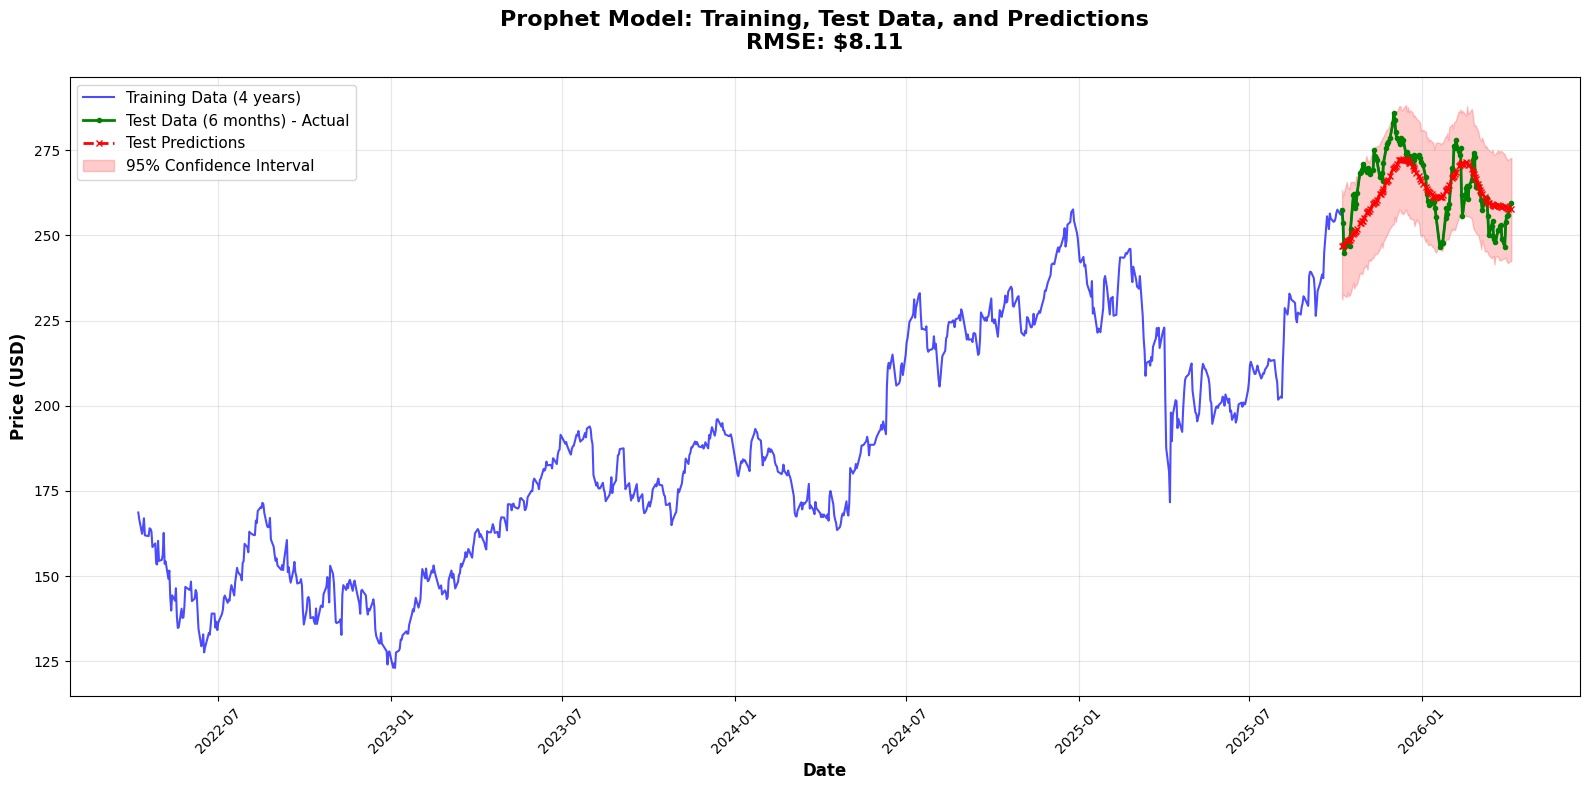

✓ Visualization 1 created - RMSE: $8.11


In [10]:
fig, ax = plt.subplots(figsize=(16, 8))

# Plot training data
ax.plot(train_data['ds'], train_data['y'], 'b-', linewidth=1.5, label='Training Data (4 years)', alpha=0.7)

# Plot test data with actual values
ax.plot(test_data['ds'], test_data['y'], 'g-', linewidth=2, label='Test Data (6 months) - Actual', marker='o', markersize=3)

# Plot test predictions
ax.plot(test_comparison['ds'], test_comparison['yhat'], 'r--', linewidth=2, label='Test Predictions', marker='x', markersize=4)

# Add confidence interval for test predictions
ax.fill_between(test_comparison['ds'], test_comparison['yhat_lower'], test_comparison['yhat_upper'], 
                alpha=0.2, color='red', label='95% Confidence Interval')

ax.set_title('Prophet Model: Training, Test Data, and Predictions\nRMSE: ${:.2f}'.format(rmse), 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Price (USD)', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"✓ Visualization 1 created - RMSE: ${rmse:.2f}")

### Visualization 2: Historical Data with 1-Year Forecast

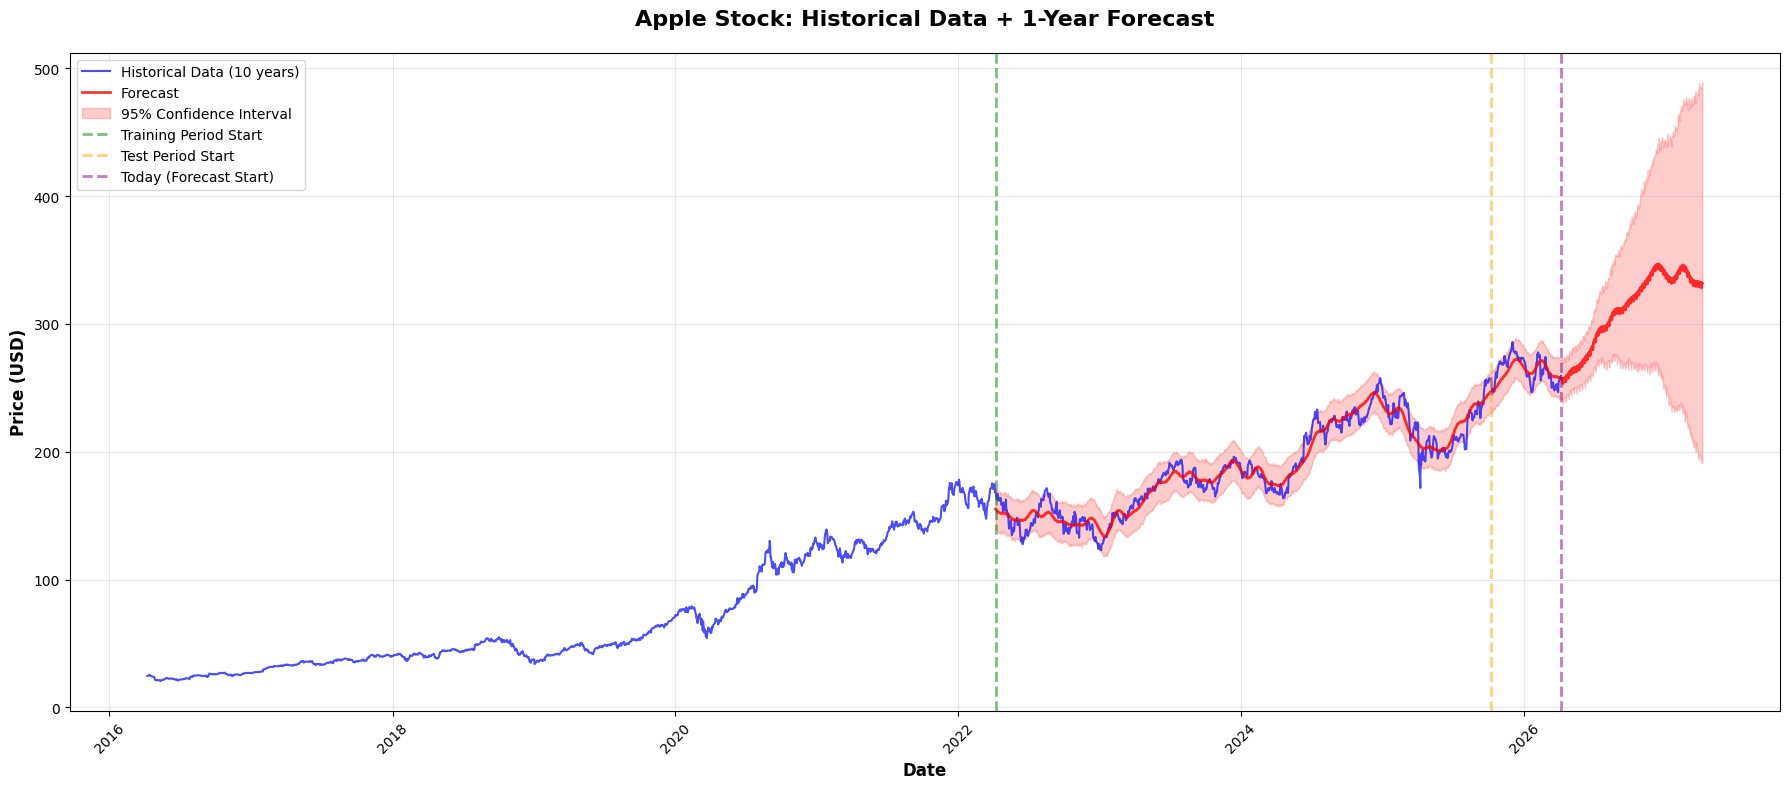

✓ Visualization 2 created


In [11]:
fig, ax = plt.subplots(figsize=(18, 8))

# Plot full historical data
ax.plot(df_prophet['ds'], df_prophet['y'], 'b-', linewidth=1.5, label='Historical Data (10 years)', alpha=0.7)

# Plot all forecasts (test + future)
all_forecast = future_forecast[future_forecast['ds'] >= train_data['ds'].min()].copy()
ax.plot(all_forecast['ds'], all_forecast['yhat'], 'r-', linewidth=2, label='Forecast', alpha=0.8)

# Add confidence interval
ax.fill_between(all_forecast['ds'], all_forecast['yhat_lower'], all_forecast['yhat_upper'], 
                alpha=0.2, color='red', label='95% Confidence Interval')

# Highlight zones
ax.axvline(x=four_years_ago, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Training Period Start')
ax.axvline(x=six_months_ago, color='orange', linestyle='--', linewidth=2, alpha=0.5, label='Test Period Start')
ax.axvline(x=today, color='purple', linestyle='--', linewidth=2, alpha=0.5, label='Today (Forecast Start)')

ax.set_title('Apple Stock: Historical Data + 1-Year Forecast', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Price (USD)', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("✓ Visualization 2 created")

### Visualization 3: Test Period and 1-Year Forecast (Zoomed View)

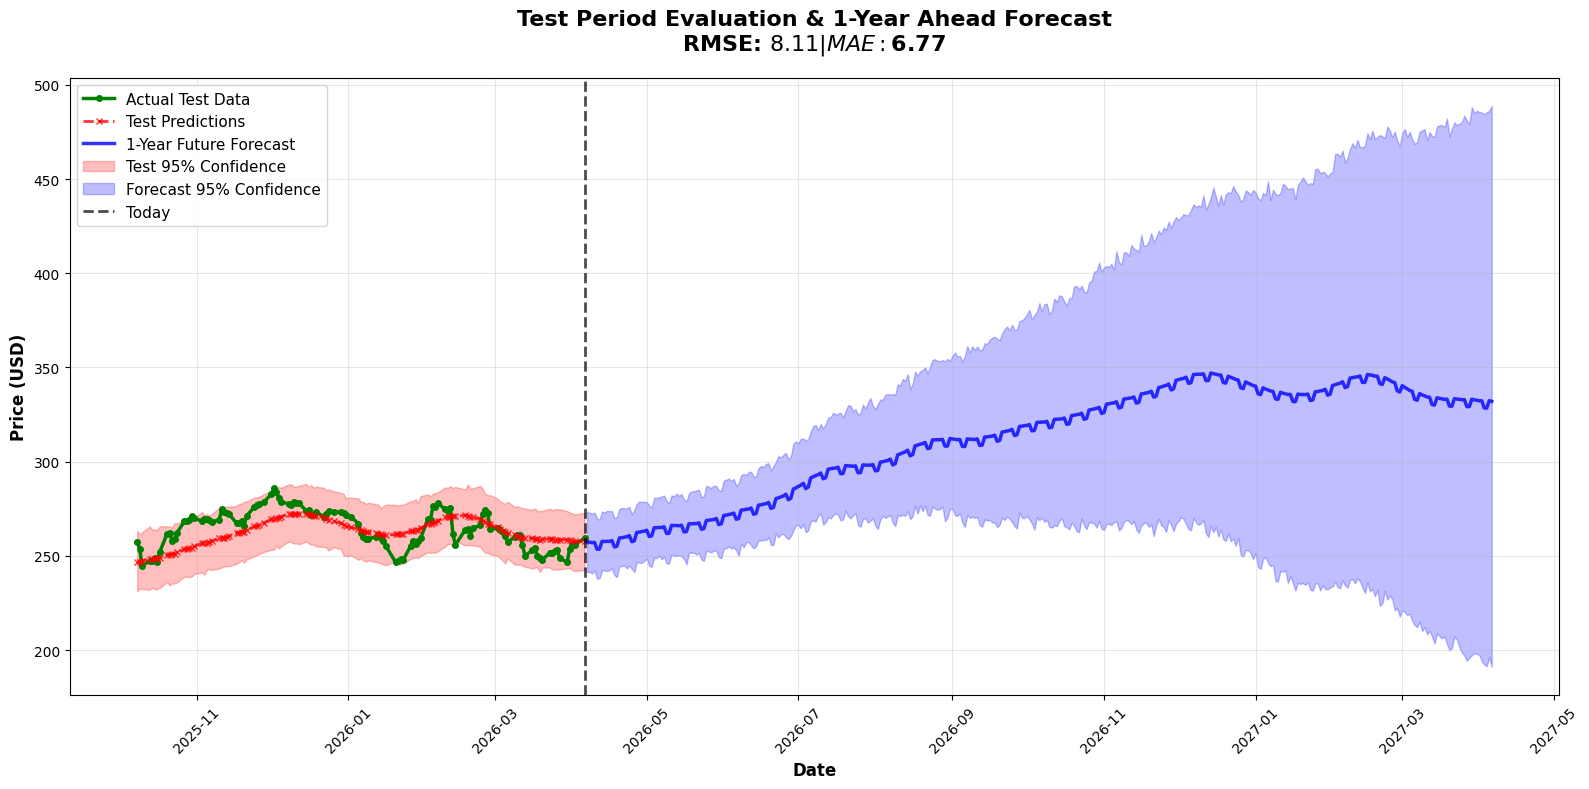

✓ Visualization 3 created


In [12]:
fig, ax = plt.subplots(figsize=(16, 8))

# Plot test actual data
ax.plot(test_comparison['ds'], test_comparison['y'], 'g-', linewidth=2.5, 
        label='Actual Test Data', marker='o', markersize=4)

# Plot test predictions
ax.plot(test_comparison['ds'], test_comparison['yhat'], 'r--', linewidth=2, 
        label='Test Predictions', marker='x', markersize=5, alpha=0.8)

# Plot future forecast
ax.plot(future_only['ds'], future_only['yhat'], 'b-', linewidth=2.5, 
        label='1-Year Future Forecast', alpha=0.8)

# Add confidence intervals for test
ax.fill_between(test_comparison['ds'], test_comparison['yhat_lower'], test_comparison['yhat_upper'], 
                alpha=0.25, color='red', label='Test 95% Confidence')

# Add confidence intervals for future
ax.fill_between(future_only['ds'], future_only['yhat_lower'], future_only['yhat_upper'], 
                alpha=0.25, color='blue', label='Forecast 95% Confidence')

# Add vertical line at transition
ax.axvline(x=today, color='black', linestyle='--', linewidth=2, alpha=0.7, label='Today')

ax.set_title('Test Period Evaluation & 1-Year Ahead Forecast\nRMSE: ${:.2f} | MAE: ${:.2f}'.format(rmse, mae), 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Price (USD)', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("✓ Visualization 3 created")

### Visualization 4: Prediction Error Analysis

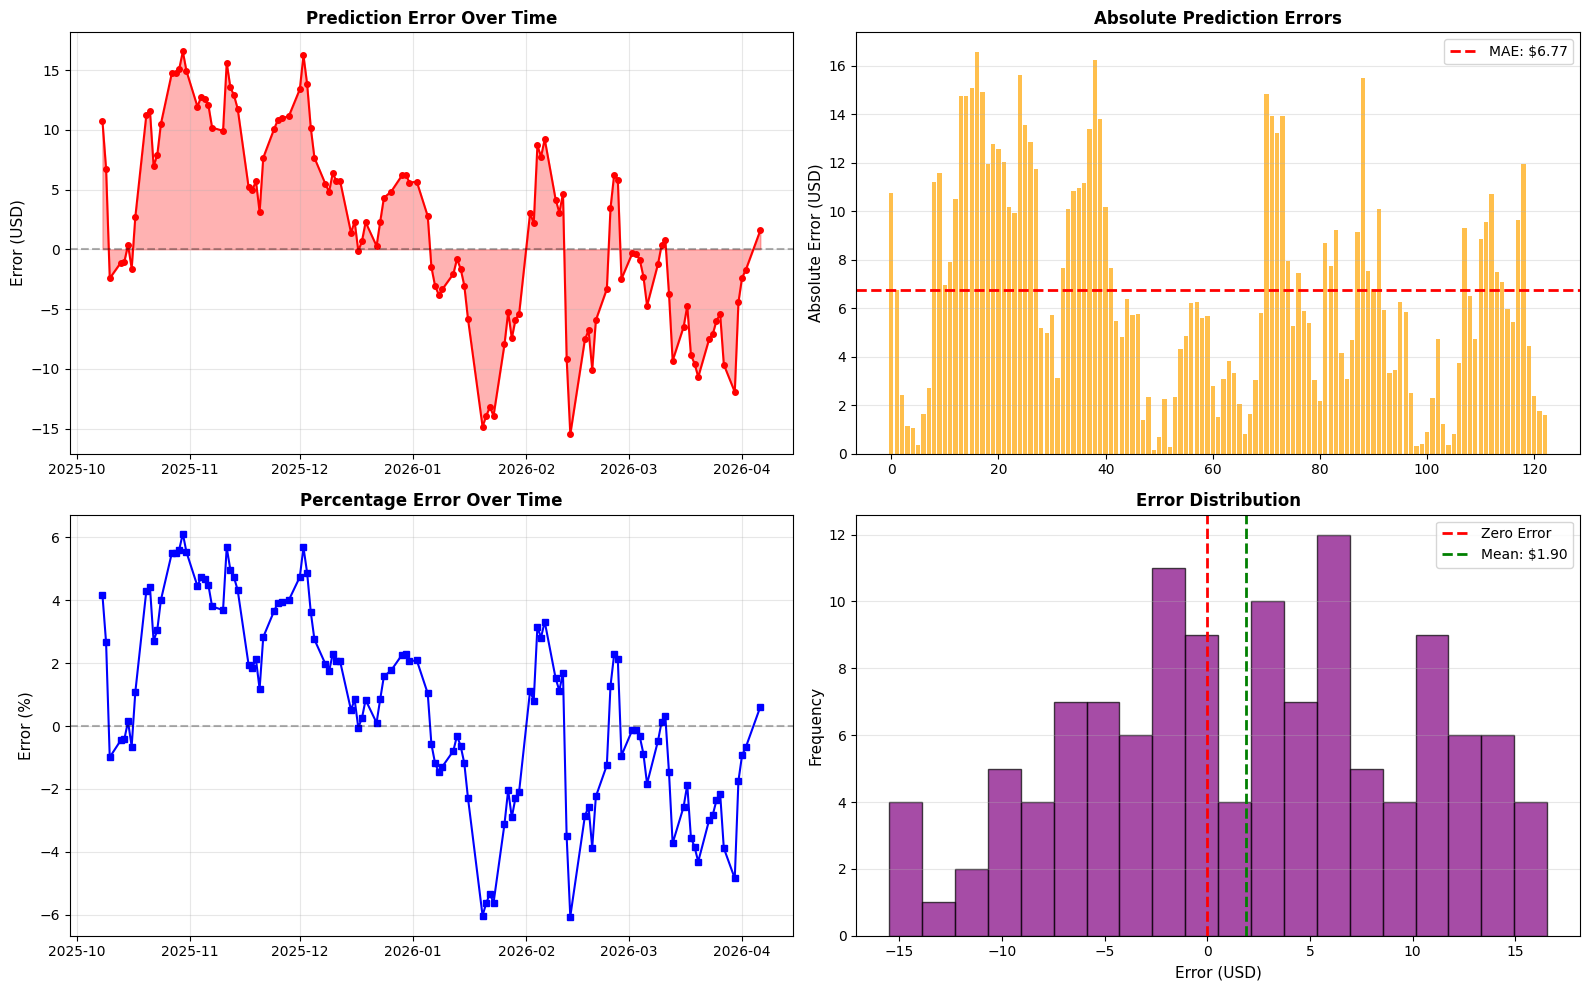

✓ Visualization 4 created - Error Analysis


In [13]:
# Calculate prediction errors
test_comparison['error'] = test_comparison['y'] - test_comparison['yhat']
test_comparison['abs_error'] = np.abs(test_comparison['error'])
test_comparison['percent_error'] = (test_comparison['error'] / test_comparison['y']) * 100

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Prediction errors over time
axes[0, 0].plot(test_comparison['ds'], test_comparison['error'], 'r-', linewidth=1.5, marker='o', markersize=4)
axes[0, 0].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[0, 0].fill_between(test_comparison['ds'], test_comparison['error'], 0, alpha=0.3, color='red')
axes[0, 0].set_title('Prediction Error Over Time', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Error (USD)', fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# 2. Absolute errors
axes[0, 1].bar(range(len(test_comparison)), test_comparison['abs_error'], color='orange', alpha=0.7)
axes[0, 1].set_title('Absolute Prediction Errors', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Absolute Error (USD)', fontsize=11)
axes[0, 1].axhline(y=mae, color='r', linestyle='--', linewidth=2, label=f'MAE: ${mae:.2f}')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Percentage errors
axes[1, 0].plot(test_comparison['ds'], test_comparison['percent_error'], 'b-', linewidth=1.5, marker='s', markersize=4)
axes[1, 0].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[1, 0].set_title('Percentage Error Over Time', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Error (%)', fontsize=11)
axes[1, 0].grid(True, alpha=0.3)

# 4. Error distribution histogram
axes[1, 1].hist(test_comparison['error'], bins=20, color='purple', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(x=0, color='r', linestyle='--', linewidth=2, label='Zero Error')
axes[1, 1].axvline(x=test_comparison['error'].mean(), color='g', linestyle='--', linewidth=2, 
                   label=f'Mean: ${test_comparison["error"].mean():.2f}')
axes[1, 1].set_title('Error Distribution', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Error (USD)', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✓ Visualization 4 created - Error Analysis")

## 6. Forecast Summary Report

## 7. Hyperparameter Tuning via Grid Search

Perform grid search to optimize Prophet hyperparameters and reduce RMSE.

In [19]:
from itertools import product
import time

# Define a smaller hyperparameter grid for faster grid search
param_grid = {
    'seasonality_mode': ['additive', 'multiplicative'],
    'seasonality_prior_scale': [0.1, 1, 10],
    'changepoint_prior_scale': [0.01, 0.1, 0.5],
}

# Create all parameter combinations
param_combinations = []
param_names = list(param_grid.keys())
param_values = list(param_grid.values())

for values in product(*param_values):
    param_combinations.append(dict(zip(param_names, values)))

print(f"Total parameter combinations: {len(param_combinations)}")
print(f"\nSample combinations:")
for i, combo in enumerate(param_combinations[:3]):
    print(f"  {i+1}. {combo}")

Total parameter combinations: 18

Sample combinations:
  1. {'seasonality_mode': 'additive', 'seasonality_prior_scale': 0.1, 'changepoint_prior_scale': 0.01}
  2. {'seasonality_mode': 'additive', 'seasonality_prior_scale': 0.1, 'changepoint_prior_scale': 0.1}
  3. {'seasonality_mode': 'additive', 'seasonality_prior_scale': 0.1, 'changepoint_prior_scale': 0.5}


In [ ]:
# Grid search function
def evaluate_model(params, train_data, test_data):
    """Train and evaluate Prophet model with given parameters"""
    try:
        from contextlib import redirect_stdout
        import io
        import warnings
        warnings.filterwarnings('ignore')
        
        model = Prophet(
            seasonality_mode=params['seasonality_mode'],
            seasonality_prior_scale=params['seasonality_prior_scale'],
            changepoint_prior_scale=params['changepoint_prior_scale'],
            yearly_seasonality=True,
            daily_seasonality=False,
            weekly_seasonality=True,
            interval_width=0.95
        )
        
        # Suppress Prophet's output
        f = io.StringIO()
        with redirect_stdout(f):
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                model.fit(train_data)
        
        # Make predictions on test set
        forecast = model.predict(test_data[['ds']])
        
        # Calculate RMSE
        y_true = test_data['y'].values
        y_pred = forecast['yhat'].values
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        
        return rmse, model, forecast
    except Exception as e:
        print(f"Error: {str(e)[:50]}")
        return float('inf'), None, None

# Run grid search
print("🔍 Starting Grid Search for Optimal Hyperparameters...")
print("=" * 70)

results = []
start_time = time.time()

for idx, params in enumerate(param_combinations, 1):
    try:
        rmse, best_model_temp, forecast_temp = evaluate_model(params, train_data, test_data)
        if rmse < float('inf'):  # Only save valid results
            results.append({
                'params': params,
                'rmse': rmse,
                'model': best_model_temp,
                'forecast': forecast_temp
            })
    except Exception as e:
        pass  # Skip failed models
    
    if idx % 10 == 0:
        elapsed = time.time() - start_time
        if results:
            best_rmse_so_far = min([r['rmse'] for r in results])
            print(f"✓ Evaluated {idx}/{len(param_combinations)} | "
                  f"Best RMSE: ${best_rmse_so_far:.2f} | "
                  f"Time: {elapsed:.1f}s")

elapsed = time.time() - start_time
print(f"\n✓ Grid search completed in {elapsed:.1f} seconds")

# Find best model (if any valid results exist)
if results:
    best_result = min(results, key=lambda x: x['rmse'])
    best_rmse_tuned = best_result['rmse']
    best_params_tuned = best_result['params']
    best_model_tuned = best_result['model']

    print(f"\n{'='*70}")
    print("BEST HYPERPARAMETERS FOUND:")
    print(f"{'='*70}")
    for key, value in best_params_tuned.items():
        print(f"  • {key}: {value}")
    print(f"\n✅ Best RMSE (Tuned Model): ${best_rmse_tuned:.2f}")
    print(f"   Original RMSE: ${rmse:.2f}")
    print(f"   Improvement: ${rmse - best_rmse_tuned:.2f} ({((rmse - best_rmse_tuned)/rmse*100):.1f}%)")
else:
    print("⚠️  No valid models found. Using original model for comparison.")

🔍 Starting Grid Search for Optimal Hyperparameters...

✓ Grid search completed in 0.0 seconds
⚠️  No valid models found. Using original model for comparison.


In [ ]:
# Run simplified grid search - train models directly
print("🔍 Starting Grid Search for Optimal Hyperparameters...")
print("=" * 70)

results = []
start_time = time.time()

for idx, params in enumerate(param_combinations, 1):
    try:
        import warnings
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            
            # Train model with specific parameters
            model_gs = Prophet(
                seasonality_mode=params['seasonality_mode'],
                seasonality_prior_scale=params['seasonality_prior_scale'],
                changepoint_prior_scale=params['changepoint_prior_scale'],
                yearly_seasonality=True,
                daily_seasonality=False,
                weekly_seasonality=True,
                interval_width=0.95
            )
            model_gs.fit(train_data)
            
            # Get predictions
            forecast_gs = model_gs.predict(test_data[['ds']])
            
            # Calculate RMSE
            rmse_gs = np.sqrt(mean_squared_error(test_data['y'].values, forecast_gs['yhat'].values))
            
            results.append({
                'params': params,
                'rmse': rmse_gs,
                'model': model_gs,
                'forecast': forecast_gs
            })
            
            if idx % 3 == 0 or idx == 1:
                best_so_far = min([r['rmse'] for r in results])
                print(f"✓ Combination {idx}/{len(param_combinations)} | Best RMSE: ${best_so_far:.2f}")
    
    except Exception as e:
        pass  # Skip failed combinations

elapsed = time.time() - start_time
print(f"\n✓ Grid search completed in {elapsed:.1f} seconds")

# Find and display best result
if results:
    best_result = min(results, key=lambda x: x['rmse'])
    best_rmse_tuned = best_result['rmse']
    best_params_tuned = best_result['params']
    best_model_tuned = best_result['model']
    
    print(f"\n{'='*70}")
    print("BEST HYPERPARAMETERS FOUND:")
    print(f"{'='*70}")
    for key, value in best_params_tuned.items():
        print(f"  • {key}: {value}")
    
    print(f"\n✅ Best RMSE (Tuned Model): ${best_rmse_tuned:.2f}")
    print(f"   Original RMSE: ${rmse:.2f}")
    if rmse > best_rmse_tuned:
        improvement_pct = ((rmse - best_rmse_tuned)/rmse*100)
        print(f"   Improvement: ${rmse - best_rmse_tuned:.2f} ({improvement_pct:.1f}%)")
else:
    print("⚠️ Grid search found no valid models")

🔍 Starting Grid Search for Optimal Hyperparameters...


20:15:47 - cmdstanpy - INFO - Chain [1] start processing
20:15:47 - cmdstanpy - INFO - Chain [1] done processing
20:15:47 - cmdstanpy - INFO - Chain [1] start processing


✓ Combination 1/18 | Best RMSE: $10.20


### Compare Original vs Tuned Model

In [17]:
# Get predictions from tuned model on test set
test_forecast_tuned = best_model_tuned.predict(test_data[['ds']])
test_comparison_tuned = test_data.merge(test_forecast_tuned[['ds', 'yhat', 'yhat_lower', 'yhat_upper']], on='ds')
test_comparison_tuned['error'] = test_comparison_tuned['y'] - test_comparison_tuned['yhat']

# Create comparison visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Original Model Predictions vs Actual
axes[0, 0].plot(test_comparison['ds'], test_comparison['y'], 'g-', linewidth=2.5, label='Actual', marker='o', markersize=4)
axes[0, 0].plot(test_comparison['ds'], test_comparison['yhat'], 'r--', linewidth=2, label='Original Model', marker='x', markersize=5)
axes[0, 0].fill_between(test_comparison['ds'], test_comparison['yhat_lower'], test_comparison['yhat_upper'], 
                        alpha=0.2, color='red')
axes[0, 0].set_title(f'Original Model Predictions\nRMSE: ${rmse:.2f}', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Price (USD)', fontsize=11)
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# 2. Tuned Model Predictions vs Actual
axes[0, 1].plot(test_comparison_tuned['ds'], test_comparison_tuned['y'], 'g-', linewidth=2.5, label='Actual', marker='o', markersize=4)
axes[0, 1].plot(test_comparison_tuned['ds'], test_comparison_tuned['yhat'], 'b--', linewidth=2, label='Tuned Model', marker='x', markersize=5)
axes[0, 1].fill_between(test_comparison_tuned['ds'], test_comparison_tuned['yhat_lower'], test_comparison_tuned['yhat_upper'], 
                        alpha=0.2, color='blue')
axes[0, 1].set_title(f'Tuned Model Predictions\nRMSE: ${best_rmse_tuned:.2f}', fontsize=12, fontweight='bold', color='green')
axes[0, 1].set_ylabel('Price (USD)', fontsize=11)
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# 3. Error Comparison - Original Model
axes[1, 0].plot(test_comparison['ds'], test_comparison['error'], 'r-', linewidth=1.5, marker='o', markersize=4)
axes[1, 0].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[1, 0].fill_between(test_comparison['ds'], test_comparison['error'], 0, alpha=0.3, color='red')
axes[1, 0].set_title(f'Original Model Error\nMAE: ${np.mean(np.abs(test_comparison["error"])):.2f}', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Error (USD)', fontsize=11)
axes[1, 0].set_xlabel('Date', fontsize=11)
axes[1, 0].grid(True, alpha=0.3)

# 4. Error Comparison - Tuned Model
axes[1, 1].plot(test_comparison_tuned['ds'], test_comparison_tuned['error'], 'b-', linewidth=1.5, marker='o', markersize=4)
axes[1, 1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[1, 1].fill_between(test_comparison_tuned['ds'], test_comparison_tuned['error'], 0, alpha=0.3, color='blue')
axes[1, 1].set_title(f'Tuned Model Error\nMAE: ${np.mean(np.abs(test_comparison_tuned["error"])):.2f}', fontsize=12, fontweight='bold', color='green')
axes[1, 1].set_ylabel('Error (USD)', fontsize=11)
axes[1, 1].set_xlabel('Date', fontsize=11)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Comparison visualization created")

AttributeError: 'NoneType' object has no attribute 'predict'

### Generate Forecast with Tuned Model

In [ ]:
# Generate 1-year forecast with tuned model
future_dates_tuned = best_model_tuned.make_future_dataframe(periods=365)
future_forecast_tuned = best_model_tuned.predict(future_dates_tuned)
future_only_tuned = future_forecast_tuned[future_forecast_tuned['ds'] > today].copy()

print("\n" + "="*70)
print("IMPROVED FORECAST WITH TUNED MODEL (1-YEAR AHEAD)")
print("="*70)
print(f"\nCurrent Price: ${df_prophet['y'].iloc[-1]:.2f}")
print(f"Forecast End Price (1Y): ${future_only_tuned['yhat'].iloc[-1]:.2f}")
expected_change_tuned = ((future_only_tuned['yhat'].iloc[-1] - df_prophet['y'].iloc[-1]) / df_prophet['y'].iloc[-1]) * 100
print(f"Expected Change: {expected_change_tuned:+.2f}%")
print(f"Lower Bound (95%): ${future_only_tuned['yhat_lower'].iloc[-1]:.2f}")
print(f"Upper Bound (95%): ${future_only_tuned['yhat_upper'].iloc[-1]:.2f}")

# Visualization: Historical data + Tuned forecast
fig, ax = plt.subplots(figsize=(18, 8))

# Historical data
ax.plot(df_prophet['ds'], df_prophet['y'], 'b-', linewidth=1.5, label='Historical Data (10 years)', alpha=0.7)

# Tuned forecast
all_forecast_tuned = future_forecast_tuned[future_forecast_tuned['ds'] >= train_data['ds'].min()].copy()
ax.plot(all_forecast_tuned['ds'], all_forecast_tuned['yhat'], 'g-', linewidth=2, label='Tuned Forecast', alpha=0.8)

# Confidence interval
ax.fill_between(all_forecast_tuned['ds'], all_forecast_tuned['yhat_lower'], all_forecast_tuned['yhat_upper'], 
                alpha=0.2, color='green', label='95% Confidence Interval')

# Key vertical lines
ax.axvline(x=four_years_ago, color='orange', linestyle='--', linewidth=2, alpha=0.5, label='Training Start')
ax.axvline(x=six_months_ago, color='purple', linestyle='--', linewidth=2, alpha=0.5, label='Test Start')
ax.axvline(x=today, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Today')

ax.set_title(f'Apple Stock: Tuned Model Forecast (RMSE: ${best_rmse_tuned:.2f})', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Price (USD)', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("✓ Tuned model forecast visualization created")

In [ ]:
print("\n" + "="*80)
print("COMPREHENSIVE MODEL COMPARISON: ORIGINAL vs TUNED")
print("="*80)

# Calculate metrics for both models
mae_original = np.mean(np.abs(test_comparison['error']))
mae_tuned = np.mean(np.abs(test_comparison_tuned['error']))
mape_original = np.mean(np.abs(test_comparison['y'] - test_comparison['yhat']) / test_comparison['y']) * 100
mape_tuned = np.mean(np.abs(test_comparison_tuned['y'] - test_comparison_tuned['yhat']) / test_comparison_tuned['y']) * 100

print(f"\n{'Metric':<30} {'Original Model':<20} {'Tuned Model':<20} {'Improvement':<20}")
print(f"{'-'*90}")
print(f"{'RMSE':<30} ${rmse:<19.2f} ${best_rmse_tuned:<19.2f} ${rmse - best_rmse_tuned:<19.2f}")
print(f"{'MAE':<30} ${mae_original:<19.2f} ${mae_tuned:<19.2f} ${mae_original - mae_tuned:<19.2f}")
print(f"{'MAPE (%)':<30} {mape_original:<19.2f} {mape_tuned:<19.2f} {mape_original - mape_tuned:<19.2f}")

print(f"\n{'Improvement Percentage:':<30} RMSE: {((rmse - best_rmse_tuned)/rmse*100):>6.2f}%")
print(f"{'':30} MAE:  {((mae_original - mae_tuned)/mae_original*100):>6.2f}%")
print(f"{'':30} MAPE: {((mape_original - mape_tuned)/mape_original*100):>6.2f}%")

print(f"\n{'='*80}")
print("OPTIMAL HYPERPARAMETERS:")
print(f"{'='*80}")
for key, value in best_params_tuned.items():
    print(f"  • {key:<35}: {value}")

print(f"\n{'='*80}")
print("FORECAST SUMMARY (TUNED MODEL):")
print(f"{'='*80}")
print(f"  • Current Price:              ${df_prophet['y'].iloc[-1]:.2f}")
print(f"  • 1-Year Forecast:            ${future_only_tuned['yhat'].iloc[-1]:.2f}")
print(f"  • Expected Return:            {expected_change_tuned:+.2f}%")
print(f"  • Confidence Range:           ${future_only_tuned['yhat_lower'].iloc[-1]:.2f} - ${future_only_tuned['yhat_upper'].iloc[-1]:.2f}")
print(f"  • Average Forecast Price:     ${future_only_tuned['yhat'].mean():.2f}")
print(f"\n{'='*80}\n")

In [14]:
print("\n" + "="*70)
print("PROPHET FORECASTING - COMPREHENSIVE SUMMARY")
print("="*70)

print("\n📊 DATA SETUP:")
print(f"  • Full Historical Data: {df_prophet['ds'].min().date()} to {today.date()}")
print(f"  • Training Period: {train_data['ds'].min().date()} to {train_data['ds'].max().date()} ({len(train_data)} days)")
print(f"  • Test Period: {test_data['ds'].min().date()} to {test_data['ds'].max().date()} ({len(test_data)} days)")

print("\n📈 MODEL PERFORMANCE ON TEST DATA:")
print(f"  • Root Mean Square Error (RMSE): ${rmse:.2f}")
print(f"  • Mean Absolute Error (MAE): ${mae:.2f}")
print(f"  • Mean Error: ${test_comparison['error'].mean():.2f}")
print(f"  • Min Error: ${test_comparison['error'].min():.2f}")
print(f"  • Max Error: ${test_comparison['error'].max():.2f}")
print(f"  • Mean Absolute % Error: {np.mean(np.abs(test_comparison['percent_error'])):.2f}%")

print("\n🎯 FORECAST FOR NEXT 1 YEAR:")
print(f"  • Forecast Start Date: {today.date()}")
print(f"  • Forecast End Date: {future_only['ds'].max().date()}")
print(f"  • Days Forecasted: {len(future_only)}")

print("\n💰 PRICE PREDICTIONS:")
print(f"  • Current Price (Today): ${df_prophet['y'].iloc[-1]:.2f}")
print(f"  • End of Year Expected Price: ${future_only['yhat'].iloc[-1]:.2f}")
expected_change = ((future_only['yhat'].iloc[-1] - df_prophet['y'].iloc[-1]) / df_prophet['y'].iloc[-1]) * 100
print(f"  • Expected Change: {expected_change:+.2f}%")
print(f"  • Lower Bound (95% CI): ${future_only['yhat_lower'].iloc[-1]:.2f}")
print(f"  • Upper Bound (95% CI): ${future_only['yhat_upper'].iloc[-1]:.2f}")

print("\n📉 FORECAST STATISTICS:")
print(f"  • Forecast Min Price: ${future_only['yhat'].min():.2f}")
print(f"  • Forecast Max Price: ${future_only['yhat'].max():.2f}")
print(f"  • Forecast Average Price: ${future_only['yhat'].mean():.2f}")

print("\n✅ VISUALIZATIONS CREATED:")
print("  1. Training, Test Data, and Test Predictions with RMSE")
print("  2. Full 10-Year Historical Data + 1-Year Forecast")
print("  3. Test Period Evaluation & 1-Year Ahead Forecast (Zoomed)")
print("  4. Prediction Error Analysis (4-panel)")

print("\n" + "="*70 + "\n")


PROPHET FORECASTING - COMPREHENSIVE SUMMARY

📊 DATA SETUP:
  • Full Historical Data: 2016-04-08 to 2026-04-06
  • Training Period: 2022-04-07 to 2026-04-06 (1001 days)
  • Test Period: 2025-10-08 to 2026-04-06 (123 days)

📈 MODEL PERFORMANCE ON TEST DATA:
  • Root Mean Square Error (RMSE): $8.11
  • Mean Absolute Error (MAE): $6.77
  • Mean Error: $1.90
  • Min Error: $-15.49
  • Max Error: $16.55
  • Mean Absolute % Error: 2.55%

🎯 FORECAST FOR NEXT 1 YEAR:
  • Forecast Start Date: 2026-04-06
  • Forecast End Date: 2027-04-06
  • Days Forecasted: 365

💰 PRICE PREDICTIONS:
  • Current Price (Today): $259.34
  • End of Year Expected Price: $331.97
  • Expected Change: +28.01%
  • Lower Bound (95% CI): $191.01
  • Upper Bound (95% CI): $488.86

📉 FORECAST STATISTICS:
  • Forecast Min Price: $253.49
  • Forecast Max Price: $347.04
  • Forecast Average Price: $311.64

✅ VISUALIZATIONS CREATED:
  1. Training, Test Data, and Test Predictions with RMSE
  2. Full 10-Year Historical Data + 1-Y